# 1. Data Loading & Feature Engineering (IBM HR Analytics Dataset)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import shap

# load the IBM HR dataset - has 1470 real employees with attrition labels
raw = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
print(f"Loaded IBM dataset: {raw.shape[0]} employees, {raw.shape[1]} features")

# map IBM department names to match our database
DEPT_MAP = {
    "Human Resources":        "HR",
    "Research & Development": "IT",
    "Sales":                  "Sales",
}

# pick the features we need and rename them to match our db columns
# OverTime yes/no becomes avg hours, EnvironmentSatisfaction becomes stress
df = pd.DataFrame({
    "age":               raw["Age"],
    "department":        raw["Department"].map(DEPT_MAP),
    "job_satisfaction":  raw["JobSatisfaction"],
    "work_life_balance": raw["WorkLifeBalance"],
    "performance_score": raw["PerformanceRating"],
    "avg_hours_worked":  raw["OverTime"].map({"Yes": 10.5, "No": 8.0}),
    "avg_stress_level":  5 - raw["EnvironmentSatisfaction"],
    "risk_label":        (raw["Attrition"] == "Yes").astype(int)
})

print(df.head())
print(f"
Shape: {df.shape}")
print(f"Departments after mapping: {df["department"].unique()}")


# 2. Attrition Distribution Analysis

In [ ]:
print("="*70)
print("ATTRITION DISTRIBUTION — IBM HR Analytics Dataset")
print("="*70)
print(f"Total employees : {len(df)}")
print(f"Left      (1)   : {df['risk_label'].sum()} ({df['risk_label'].mean()*100:.1f}%)")
print(f"Stayed    (0)   : {(df['risk_label']==0).sum()} ({(df['risk_label']==0).mean()*100:.1f}%)")
print("="*70)
print("\nAttrition by Department:")
print(df.groupby("department")["risk_label"].value_counts().unstack(fill_value=0))
print("="*70)

# Visualise class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
df["risk_label"].value_counts().plot(kind="bar", ax=axes[0],
    color=["steelblue", "tomato"], edgecolor="black")
axes[0].set_xticklabels(["Stayed (0)", "Left (1)"], rotation=0)
axes[0].set_title("Overall Attrition Distribution")
axes[0].set_ylabel("Count")

# By department
dept_counts = df.groupby("department")["risk_label"].value_counts().unstack(fill_value=0)
dept_counts.plot(kind="bar", ax=axes[1], color=["steelblue", "tomato"], edgecolor="black")
axes[1].set_title("Attrition by Department")
axes[1].set_ylabel("Count")
axes[1].legend(["Stayed", "Left"])
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()



# 3. Data Preparation & Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

# 80/20 split, stratified so both sets have same ratio of leavers
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["risk_label"]
)

X_train = pd.get_dummies(train_df.drop(columns=["risk_label"]))
y_train = train_df["risk_label"]

X_test = pd.get_dummies(test_df.drop(columns=["risk_label"]))
y_test = test_df["risk_label"]

# make sure test has same columns as train (one-hot encoding can differ)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"Training: {len(X_train)} | Testing: {len(X_test)}")
print(f"Features: {list(X_train.columns)}")



# 4. Random Forest Model Training

In [ ]:
# train a basic random forest first to see how it does
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("Model trained successfully on the corrected data!")


Model trained successfully on the corrected data!


# 5. Random Forest Model Evaluation

In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# decision tree as a simple baseline to compare against random forest
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.85      0.84      0.84       183
           1       0.64      0.65      0.64        79

    accuracy                           0.78       262
   macro avg       0.74      0.74      0.74       262
weighted avg       0.78      0.78      0.78       262



# 6. Hyperparameter Tuning with GridSearchCV

In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# try different combinations of hyperparameters to find the best one
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# test all combinations with 3-fold cross validation 
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,             
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

# use whatever came out best
print(f"Best Parameters Found: {grid_search.best_params_}")
best_rf = grid_search.best_estimator_


rf = best_rf 

# Evaluate the optimized model
print("Model optimized and ready!")
print(classification_report(y_test, rf.predict(X_test)))



# need numeric for shap
X_train = X_train.astype(float)

import shap
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_train)




Best Parameters Found: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Model optimized and ready!
              precision    recall  f1-score   support

           0       0.82      0.92      0.87       183
           1       0.74      0.53      0.62        79

    accuracy                           0.80       262
   macro avg       0.78      0.72      0.74       262
weighted avg       0.79      0.80      0.79       262



# 7. Decision Tree Model (Baseline Comparison)

C:\Users\Chenu\AppData\Local\Temp\ipykernel_30696\1795883334.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(correct_shap_values, X_train)
c:\Users\Chenu\AppData\Local\Programs\Python\Python314\Lib\site-packages\shap\plots\_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
c:\Users\Chenu\AppData\Local\Programs\Python\Python314\Lib\site-packages\shap\plots\_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence th

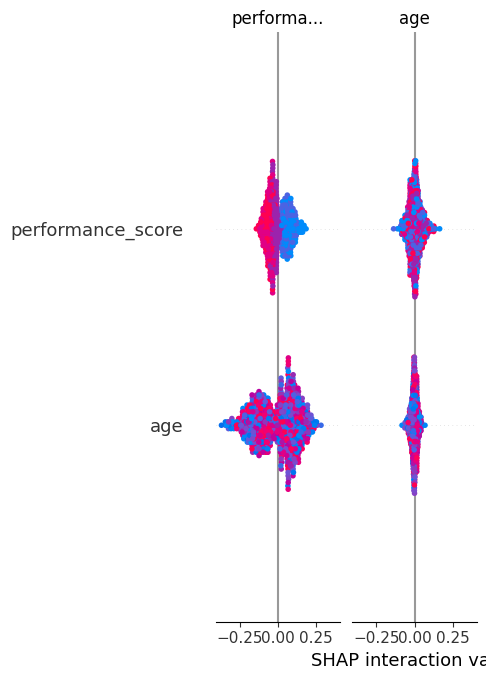

In [7]:


# shap needs float values
X_train = X_train.astype(float)

# tree explainer works specifically with tree-based models like RF
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_train)

# shap returns different formats depending on version, need to handle both

if isinstance(shap_values, list):
    # Use index 1 for the 'Positive' class (High Risk)
    correct_shap_values = shap_values[1]
else:
   
    correct_shap_values = shap_values


shap.summary_plot(correct_shap_values, X_train)


# 8. LIME (Local Interpretable Model-Agnostic Explanations)

Initializing LIME explainer...

Generating LIME explanation for test employee 0...

=== LIME EXPLANATION (Top Features) ===
avg_stress_level > 4.00: 0.3872
job_satisfaction <= 2.00: 0.2152
work_life_balance > 4.00: -0.1209
avg_hours_worked <= 6.83: -0.0755
performance_score > 4.00: -0.0626
department_Sales <= 0.00: -0.0616
department_Marketing <= 0.00: 0.0420
department_IT <= 0.00: 0.0125


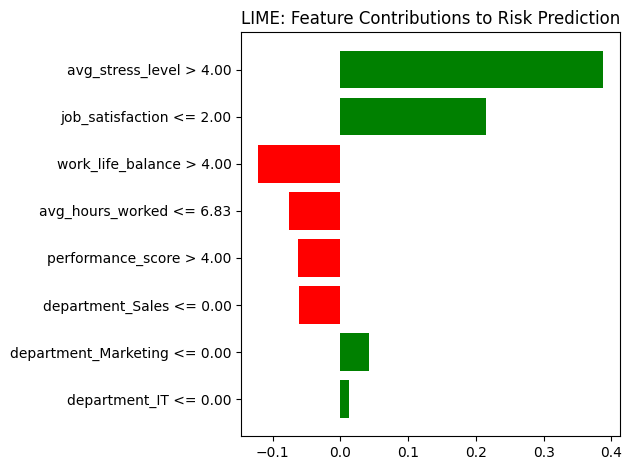


 LIME explanation complete!


In [8]:

import lime
from lime import lime_tabular

# LIME is another explainability method - comparing it with SHAP
print("Initializing LIME explainer...")

# Create LIME explainer
lime_explainer = lime_tabular.LimeTabularExplainer(
    X_train.values, 
    feature_names=X_train.columns.tolist(),
    class_names=['Low Risk', 'High Risk'],
    mode='classification',
    discretize_continuous=True
)

# Explain the first test employee
employee_idx = 0
print(f"\nGenerating LIME explanation for test employee {employee_idx}...")

# lime needs a function that takes numpy arrays not dataframes
def predict_proba_wrapper(X):
    return rf.predict_proba(pd.DataFrame(X, columns=X_train.columns))

lime_exp = lime_explainer.explain_instance(
    X_test.iloc[employee_idx].values,  # Pass as numpy array
    predict_proba_wrapper,  # Use wrapper function
    num_features=8
)

# Show explanation
print("\n=== LIME EXPLANATION (Top Features) ===")
for feature, weight in lime_exp.as_list():
    print(f"{feature}: {weight:.4f}")

# Visualize
fig = lime_exp.as_pyplot_figure()
plt.title("LIME: Feature Contributions to Risk Prediction")
plt.tight_layout()
plt.show()

print("\n LIME explanation complete!")


# 9. XGBoost Model Training & Comparison

TRAINING XGBOOST MODEL
Using existing train/test split from Random Forest
Training samples: 1044
Test samples: 262

XGBOOST PERFORMANCE
Accuracy:  0.809
Precision: 0.723
Recall:    0.595
F1-Score:  0.653
AUC-ROC:   0.915

MODEL COMPARISON
Random Forest AUC: 0.904
XGBoost AUC:       0.915

Random Forest F1:  0.618
XGBoost F1:        0.653

XGBOOST FEATURE IMPORTANCE
              feature  importance
     avg_stress_level    0.366762
     job_satisfaction    0.156115
    work_life_balance    0.131729
    performance_score    0.096021
     avg_hours_worked    0.059456
        department_IT    0.040587
department_Operations    0.040069
                  age    0.039558


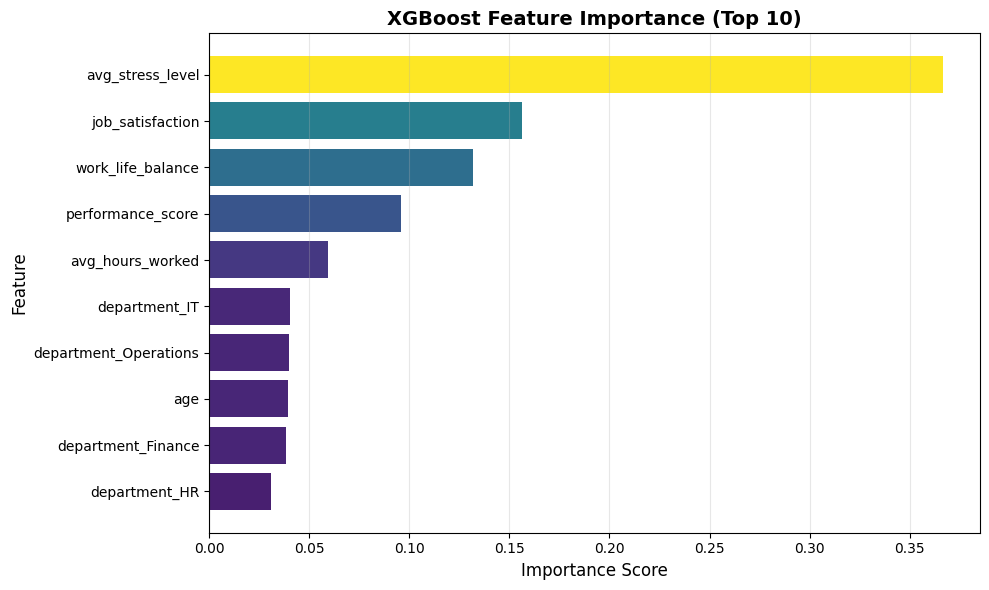

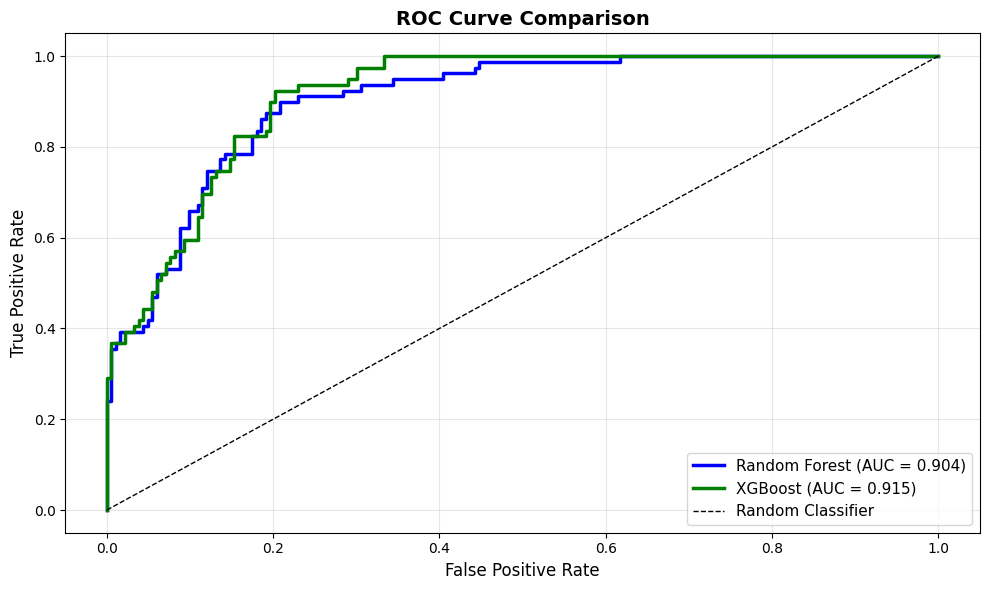

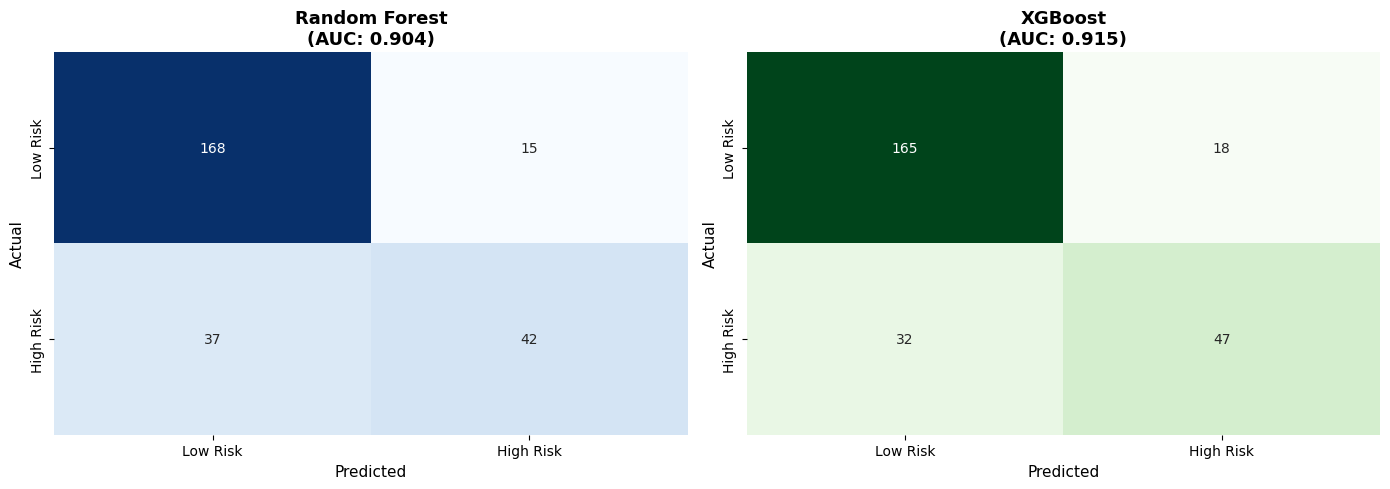


 XGBoost Analysis Complete!


In [9]:

import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("TRAINING XGBOOST MODEL")
print("=" * 60)
print(f"Using existing train/test split from Random Forest")
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}\n")

# 1. TRAIN XGBOOST
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    subsample=0.8,
    colsample_bytree=0.8
)

xgb_model.fit(X_train, y_train)

# 2. PREDICTIONS 
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# 3. EVALUATION METRICS
print("=" * 60)
print("XGBOOST PERFORMANCE")
print("=" * 60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb, zero_division=0):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_xgb):.3f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_xgb):.3f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_pred_proba_xgb):.3f}")

# 4. COMPARE WITH  EXISTING RANDOM FOREST
y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(f"Random Forest AUC: {roc_auc_score(y_test, y_pred_proba_rf):.3f}")
print(f"XGBoost AUC:       {roc_auc_score(y_test, y_pred_proba_xgb):.3f}")
print(f"\nRandom Forest F1:  {f1_score(y_test, y_pred_rf):.3f}")
print(f"XGBoost F1:        {f1_score(y_test, y_pred_xgb):.3f}")

# 5. FEATURE IMPORTANCE
xgb_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n" + "=" * 60)
print("XGBOOST FEATURE IMPORTANCE")
print("=" * 60)
print(xgb_importance.head(8).to_string(index=False))

# 6. VISUALIZATIONS

# Feature Importance (Top 10)
plt.figure(figsize=(10, 6))
top_features = xgb_importance.head(10)
colors = plt.cm.viridis(top_features['importance'] / top_features['importance'].max())
plt.barh(top_features['feature'], top_features['importance'], color=colors)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('XGBoost Feature Importance (Top 10)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# ROC Curves Comparison
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)

plt.figure(figsize=(10, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_pred_proba_rf):.3f})', 
         linewidth=2.5, color='blue')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_pred_proba_xgb):.3f})', 
         linewidth=2.5, color='green')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Confusion Matrices Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Low Risk', 'High Risk'], 
            yticklabels=['Low Risk', 'High Risk'], cbar=False)
axes[0].set_title(f'Random Forest\n(AUC: {roc_auc_score(y_test, y_pred_proba_rf):.3f})', 
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=11)
axes[0].set_xlabel('Predicted', fontsize=11)

# XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', ax=axes[1], 
            xticklabels=['Low Risk', 'High Risk'], 
            yticklabels=['Low Risk', 'High Risk'], cbar=False)
axes[1].set_title(f'XGBoost\n(AUC: {roc_auc_score(y_test, y_pred_proba_xgb):.3f})', 
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Actual', fontsize=11)
axes[1].set_xlabel('Predicted', fontsize=11)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print(" XGBoost Analysis Complete!")
print("=" * 60)


# 10. Comprehensive Model Performance Comparison (Test Set)


 COMPREHENSIVE MODEL PERFORMANCE COMPARISON
        Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC
Random Forest     0.802      0.737   0.532     0.618    0.904
      XGBoost     0.809      0.723   0.595     0.653    0.915

 BEST PERFORMER: XGBoost (AUC-ROC: 0.915)


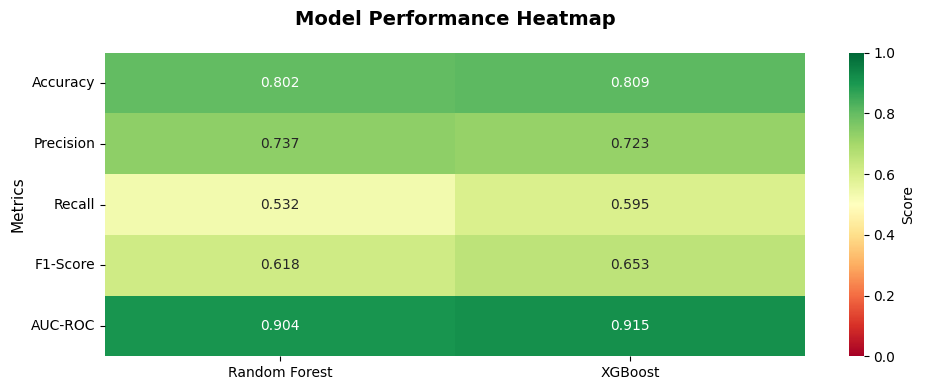

In [10]:

# Create comprehensive comparison
comparison_enhanced = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_rf, zero_division=0),
        precision_score(y_test, y_pred_xgb, zero_division=0)
    ],
    'Recall': [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    'AUC-ROC': [
        roc_auc_score(y_test, y_pred_proba_rf),
        roc_auc_score(y_test, y_pred_proba_xgb)
    ]
}).round(3)


print("\n" + "="*80)
print(" COMPREHENSIVE MODEL PERFORMANCE COMPARISON")
print("="*80)
print(comparison_enhanced.to_string(index=False))
print("="*80)

# Determine winner
best_model_name = comparison_enhanced.loc[comparison_enhanced['AUC-ROC'].idxmax(), 'Model']
best_auc = comparison_enhanced['AUC-ROC'].max()

print(f"\n BEST PERFORMER: {best_model_name} (AUC-ROC: {best_auc:.3f})")
print("="*80)

# Visualize as heatmap
import seaborn as sns
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    comparison_enhanced.set_index('Model').T, 
    annot=True, 
    fmt='.3f', 
    cmap='RdYlGn', 
    center=0.5,
    vmin=0, 
    vmax=1,
    cbar_kws={'label': 'Score'},
    ax=ax
)
ax.set_title('Model Performance Heatmap', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('')
ax.set_ylabel('Metrics', fontsize=11)
plt.tight_layout()
plt.show()


# 11. Cross-Validation Analysis

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import xgboost as xgb

print("=" * 70)
print("CROSS-VALIDATION ANALYSIS")
print("=" * 70)

X_full = pd.get_dummies(df.drop(columns=["risk_label"]))
y_full = df["risk_label"]

print(f"Total samples: {len(X_full)}")
print(f"Features: {X_full.shape[1]}")
print(f"Left (1): {y_full.sum()} ({y_full.mean()*100:.1f}%)")
print(f"Stayed (0): {(y_full==0).sum()} ({(y_full==0).mean()*100:.1f}%)\n")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── RANDOM FOREST ──
print("-" * 70)
print("Random Forest - 5-Fold Cross-Validation")
print("-" * 70)

cv_accuracy_rf  = cross_val_score(rf, X_full, y_full, cv=cv, scoring='accuracy')
cv_precision_rf = cross_val_score(rf, X_full, y_full, cv=cv, scoring='precision')
cv_recall_rf    = cross_val_score(rf, X_full, y_full, cv=cv, scoring='recall')
cv_f1_rf        = cross_val_score(rf, X_full, y_full, cv=cv, scoring='f1')
cv_roc_auc_rf   = cross_val_score(rf, X_full, y_full, cv=cv, scoring='roc_auc')

print(f"Accuracy:  {cv_accuracy_rf.mean():.3f} (±{cv_accuracy_rf.std():.3f})")
print(f"Precision: {cv_precision_rf.mean():.3f} (±{cv_precision_rf.std():.3f})")
print(f"Recall:    {cv_recall_rf.mean():.3f} (±{cv_recall_rf.std():.3f})")
print(f"F1-Score:  {cv_f1_rf.mean():.3f} (±{cv_f1_rf.std():.3f})")
print(f"AUC-ROC:   {cv_roc_auc_rf.mean():.3f} (±{cv_roc_auc_rf.std():.3f})")

print("\nFold AUC-ROC Scores:")
for i, score in enumerate(cv_roc_auc_rf, 1):
    print(f"  Fold {i}: {score:.3f}")

# ── XGBOOST ──
print("\n" + "-" * 70)
print("XGBoost - 5-Fold Cross-Validation")
print("-" * 70)

cv_accuracy_xgb  = cross_val_score(xgb_model, X_full, y_full, cv=cv, scoring='accuracy')
cv_precision_xgb = cross_val_score(xgb_model, X_full, y_full, cv=cv, scoring='precision')
cv_recall_xgb    = cross_val_score(xgb_model, X_full, y_full, cv=cv, scoring='recall')
cv_f1_xgb        = cross_val_score(xgb_model, X_full, y_full, cv=cv, scoring='f1')
cv_roc_auc_xgb   = cross_val_score(xgb_model, X_full, y_full, cv=cv, scoring='roc_auc')

print(f"Accuracy:  {cv_accuracy_xgb.mean():.3f} (±{cv_accuracy_xgb.std():.3f})")
print(f"Precision: {cv_precision_xgb.mean():.3f} (±{cv_precision_xgb.std():.3f})")
print(f"Recall:    {cv_recall_xgb.mean():.3f} (±{cv_recall_xgb.std():.3f})")
print(f"F1-Score:  {cv_f1_xgb.mean():.3f} (±{cv_f1_xgb.std():.3f})")
print(f"AUC-ROC:   {cv_roc_auc_xgb.mean():.3f} (±{cv_roc_auc_xgb.std():.3f})")

print("\nFold AUC-ROC Scores:")
for i, score in enumerate(cv_roc_auc_xgb, 1):
    print(f"  Fold {i}: {score:.3f}")

# ── COMPARISON TABLE ──
print("\n" + "=" * 70)
print("MODEL COMPARISON (Cross-Validation)")
print("=" * 70)

comparison = pd.DataFrame({
    'Model':     ['Random Forest', 'XGBoost'],
    'Accuracy':  [cv_accuracy_rf.mean(),  cv_accuracy_xgb.mean()],
    'Precision': [cv_precision_rf.mean(), cv_precision_xgb.mean()],
    'Recall':    [cv_recall_rf.mean(),    cv_recall_xgb.mean()],
    'F1-Score':  [cv_f1_rf.mean(),        cv_f1_xgb.mean()],
    'AUC-ROC':   [cv_roc_auc_rf.mean(),   cv_roc_auc_xgb.mean()],
    'Std Dev':   [cv_roc_auc_rf.std(),    cv_roc_auc_xgb.std()],
    'Stability': ['HIGH' if cv_roc_auc_rf.std() < 0.05 else 'MEDIUM',
                  'HIGH' if cv_roc_auc_xgb.std() < 0.05 else 'MEDIUM']
}).round(3)

print(comparison.to_string(index=False))
best_model = 'XGBoost' if cv_roc_auc_xgb.mean() > cv_roc_auc_rf.mean() else 'Random Forest'
print(f"\nBest Model (AUC-ROC): {best_model}")

# ── BOX PLOT ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot([cv_roc_auc_rf, cv_roc_auc_xgb], tick_labels=['Random Forest', 'XGBoost'])
axes[0].set_ylabel('AUC-ROC'); axes[0].set_title('CV: AUC-ROC Distribution')
axes[0].set_ylim(0.5, 1.0); axes[0].grid(axis='y', alpha=0.3)
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random Guess')
axes[0].legend()

means = [cv_roc_auc_rf.mean(), cv_roc_auc_xgb.mean()]
stds  = [cv_roc_auc_rf.std(),  cv_roc_auc_xgb.std()]
bars  = axes[1].bar(['Random Forest', 'XGBoost'], means, yerr=stds, capsize=10,
                     color=['blue', 'green'], alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Mean AUC-ROC'); axes[1].set_title('CV: Mean Performance')
axes[1].set_ylim(0.5, 1.0); axes[1].grid(axis='y', alpha=0.3)
for bar, mean, std in zip(bars, means, stds):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{mean:.3f}\n(±{std:.3f})', ha='center', va='bottom', fontsize=10)
plt.tight_layout(); plt.show()

print("\nCross-Validation Complete!")



# 12. SHAP (SHapley Additive exPlanations)

In [12]:


# explain a single employee's prediction
employee_idx = 0
if isinstance(shap_values, list):
    # For binary classification, shap_values is [class_0, class_1]
    # We want class 1 (High Risk)
    sv = shap_values[1][employee_idx]
else:
    # Handle different SHAP output formats
    if len(shap_values.shape) == 3:
        # Shape: (n_samples, n_features, n_classes)
        sv = shap_values[employee_idx, :, 1]  # Class 1 = High Risk
    else:
        # Shape: (n_samples, n_features)
        sv = shap_values[employee_idx]

# Create the explanation dataframe
explanation_df = pd.DataFrame({
    "feature": X_train.columns,
    "shap_value": sv
})

print("Full SHAP Explanation:")
print(explanation_df.sort_values("shap_value", key=abs, ascending=False))
print("\n" + "="*60 + "\n")




# only look at the features HR actually cares about
behavioural_features = [
    "avg_hours_worked",
    "avg_stress_level",
    "work_life_balance",
    "job_satisfaction",
    "performance_score"
]

filtered = explanation_df[
    explanation_df["feature"].isin(behavioural_features)
]

# grab the top 3 biggest factors
top_risk_factors = filtered.reindex(
    filtered["shap_value"].abs().sort_values(ascending=False).index
).head(3)

print("Top 3 Behavioral Risk Factors:")
print(top_risk_factors)

Full SHAP Explanation:
                  feature  shap_value
5        avg_stress_level   -0.227340
2        job_satisfaction    0.115382
3       work_life_balance   -0.069131
1       performance_score   -0.039974
10  department_Operations    0.026877
4        avg_hours_worked   -0.026777
0                     age   -0.006590
7           department_HR    0.002288
8           department_IT    0.000921
6      department_Finance   -0.000742
9    department_Marketing    0.000150
11       department_Sales   -0.000049


Top 3 Behavioral Risk Factors:
             feature  shap_value
5   avg_stress_level   -0.227340
2   job_satisfaction    0.115382
3  work_life_balance   -0.069131



# 13. Automated Risk Report Generation

In [13]:
def generate_risk_report(employee_id, risk_label, top_features, original_row):
    # convert 0/1 to readable label
    risk = "High" if risk_label == 1 else "Low"
    
    negative_factors = []
    positive_factors = []
    actions = []

    # go through each top feature and categorize it based on thresholds
    for _, row in top_features.iterrows():
        feature = row["feature"]
        value = original_row[feature]
        
        # --- Logic for Average Hours Worked ---
        if feature == "avg_hours_worked":
            if value >= 9.5:
                negative_factors.append(f"working hours are high ({value:.1f} hrs/day)")
                actions.append("reduce overtime and rebalance workload")
            elif value < 7:
                negative_factors.append(f"working hours are unusually low ({value:.1f} hrs/day)")
                actions.append("investigate potential disengagement or underutilization")
            else:
                positive_factors.append(f"working hours are balanced ({value:.1f} hrs/day)")

        # --- Logic for Stress Level ---
        elif feature == "avg_stress_level":
            if value >= 4:
                negative_factors.append(f"stress levels are critical ({value:.1f}/5)")
                actions.append("initiate immediate stress management counseling")
            elif value >= 3:
                negative_factors.append(f"stress levels are elevated ({value:.1f}/5)")
                actions.append("schedule wellbeing check-in")
            else:
                positive_factors.append("stress levels are within a healthy range")

        # --- Logic for Work-Life Balance ---
        elif feature == "work_life_balance":
            if value <= 2:
                negative_factors.append(f"work–life balance is poor ({int(value)}/5)")
                actions.append("offer flexible working arrangements")
            elif value == 3:
                negative_factors.append(f"work–life balance is moderate ({int(value)}/5)")
            else:
                positive_factors.append("work–life balance is strong")

        # --- Logic for Job Satisfaction ---
        elif feature == "job_satisfaction":
            if value <= 2:
                negative_factors.append(f"job satisfaction is low ({int(value)}/5)")
                actions.append("conduct role alignment and career progression review")
            elif value >= 4:
                positive_factors.append(f"job satisfaction is high ({int(value)}/5)")
            
        # --- Logic for Performance Score ---
        elif feature == "performance_score":
            if value <= 2:
                negative_factors.append(f"performance is lagging ({int(value)}/5)")
                actions.append("provide targeted performance coaching")
            elif value >= 4:
                positive_factors.append(f"performance is strong ({int(value)}/5)")

    # build the explanation text
    if negative_factors:
        interpretation = "Key risk factors include: " + "; ".join(negative_factors) + "."
        if positive_factors:
            interpretation += " However, " + "; ".join(positive_factors) + "."
    elif positive_factors:
        interpretation = "The employee shows strong indicators: " + "; ".join(positive_factors) + "."
    else:
        interpretation = "The employee shows a mix of average indicators with no extreme outliers."

    # remove duplicate actions and build action text
    actions = list(dict.fromkeys(actions))
    
    if risk == "High":
        if actions:
            action_text = "Urgent: " + "; ".join(actions) + "."
        else:
            action_text = "Review specific department benchmarks as no single factor is critical."
    else:
        if actions:
            action_text = "Monitor: " + "; ".join(actions) + "."
        else:
            action_text = "Continue routine monitoring; recognize strong performance where applicable."

    # put it all together
    report = f"""
Employee Risk Report
--------------------
Employee ID: {employee_id}
Risk Prediction: {risk}

Interpretation:
{interpretation}

Recommended Action:
{action_text}
"""
    return report


# 14. ROC Curve & Precision-Recall Analysis

=== MODEL EVALUATION METRICS ===
Accuracy: 0.802
Precision: 0.737
Recall: 0.532
F1-Score: 0.618
AUC-ROC: 0.904


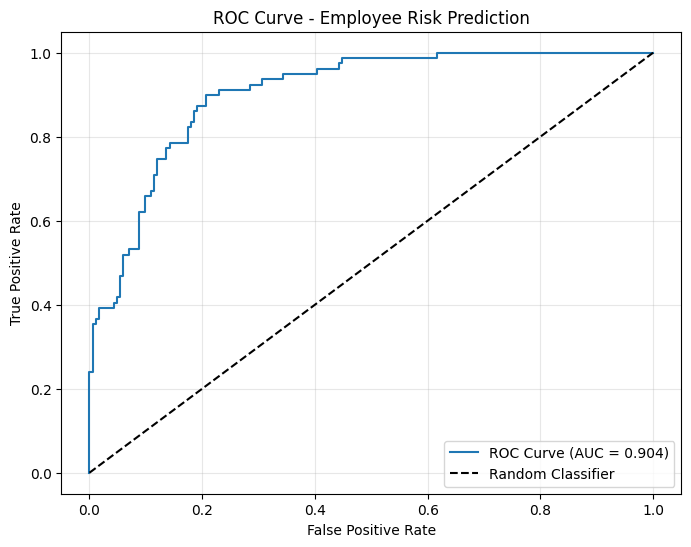

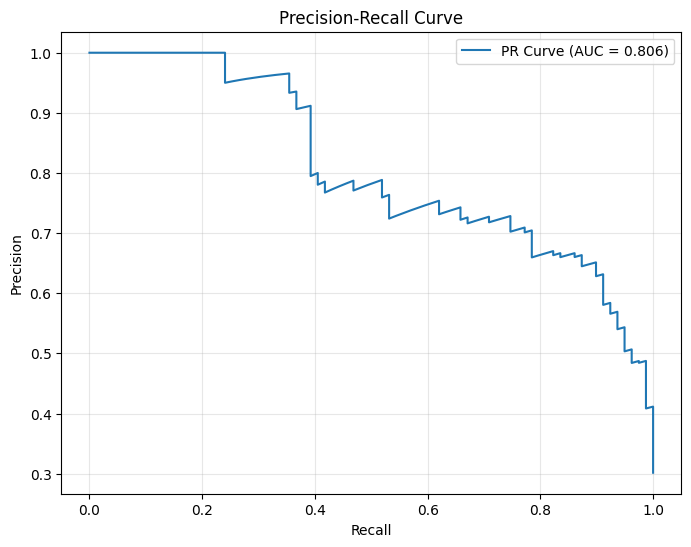

In [14]:


from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    accuracy_score, precision_score, recall_score, f1_score,
    auc 
)

# get predictions to evaluate how well the model actually does
y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:, 1]

# these are the main metrics we report
print("=== MODEL EVALUATION METRICS ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall: {recall_score(y_test, y_pred):.3f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.3f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.3f}")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_pred_proba):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Employee Risk Prediction')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR Curve (AUC = {auc(recall, precision):.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# 15. Employee Risk Report - Demonstration

In [ ]:
def get_employee_report_by_idx(idx):
    """quick way to test the report on any employee in the dataset."""

    original_employee = df.iloc[idx]

    X_all = pd.get_dummies(df.drop(columns=["risk_label"]))
    X_all = X_all.reindex(columns=X_train.columns, fill_value=0)

    shap_values_all = explainer.shap_values(X_all.astype(float))
    if isinstance(shap_values_all, list):
        correct_shap_all = shap_values_all[1]
    else:
        correct_shap_all = shap_values_all

    employee_features = X_all.iloc[[idx]]
    risk_prediction = rf.predict(employee_features)[0]

    if len(correct_shap_all.shape) == 3:
        sv = correct_shap_all[idx, :, 1]
    else:
        sv = correct_shap_all[idx]

    explanation_df = pd.DataFrame({
        "feature":    X_train.columns,
        "shap_value": sv
    })

    behavioural_features = [
        "avg_hours_worked", "avg_stress_level",
        "work_life_balance", "job_satisfaction", "performance_score"
    ]
    filtered = explanation_df[explanation_df["feature"].isin(behavioural_features)]
    top_risk_factors = filtered.reindex(
        filtered["shap_value"].abs().sort_values(ascending=False).index
    ).head(3)

    report = generate_risk_report(
        employee_id=idx,
        risk_label=risk_prediction,
        top_features=top_risk_factors,
        original_row=original_employee
    )
    print(report)


# Demonstrate on first employee in dataset
get_employee_report_by_idx(0)


In [16]:
import joblib

# save the model so the flask app can load it
joblib.dump(rf, "rf_model.pkl")
print("Model saved as rf_model.pkl")


 Model saved as rf_model.pkl
